# Homework: Multimodal Models - Image Captioning and Visual Question Answering

**Goal**

In this assignment, you will experiment with multimodal models that combine vision and language.

You will use a pretrained model to:

1. Generate a caption for an image.
2. Answer questions about an image.

You will also analyze the model's strengths, weaknesses, and possible failure cases.

## Task 1 - Image Captioning (30 Points)

**Description**

Given an input image, use a pretrained multimodal model to generate a textual description of the image.

Example:

**Input**: An image of a dog running in a park.

**Output**: A dog is running on grass in a park.

**Requirements**

Use at least 5 different images.

The images should include:

* At least one image with people
* At least one image with animals
* At least one indoor scene
* At least one outdoor scene
* At least one image with multiple objects

You may use your own images or images from an open dataset.

**Suggested Models**

You may use one of the following:

* Salesforce/blip-image-captioning-base
* Salesforce/blip-image-captioning-large
* microsoft/git-base
* Any other image-captioning model from HuggingFace

**Deliverables**

1. Present your images and model captions clearly

    Display each image together with the caption generated by the model.

2. Analyze model failures

    Choose at least 2 examples where the model made a mistake or gave an incomplete caption.

    For each example, explain:

    * What the model predicted
    * What the correct description should be
    * Why the model may have failed

    For example :

    "The model described the image as “a person sitting at a table,” but it missed the laptop and the coffee cup.
    This may have happened because the person was the most visually dominant object, while the smaller objects were less noticeable."


In [1]:
# Installs the dependencies this notebook needs.
%pip install -q "transformers>=4.40" pillow matplotlib requests

import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} | device: {device}")

Note: you may need to restart the kernel to use updated packages.
torch 2.2.2+cu121 | device: cpu


In [2]:
# Get Hugging Face Token
from getpass import getpass
#from google.colab import userdata
import os

def get_hf_token(name="HF_TOKEN"):
    hf_token = None
    try:
        hf_token = os.environ[name]
        print("HF Token is taken from the environmental parameters")
    except:
        raise Exception("HF Token could not be found")
        """
        try:
            hf_token = getpass("Enter HF Token: ")
            os.environ[name] = hf_token
            print("HF Token is taken from getpass")
        except:
            raise Exception("HF Token could not be found")
        """

    assert hf_token is not None, "HF Token is None"
    return hf_token

In [ ]:
# Use the *large* checkpoint: a strong model for this task.
import os
from transformers import logging as hf_logging

# Silence redundent warnings.
hf_logging.set_verbosity_error()

MODEL_NAME = "Salesforce/blip-image-captioning-large"

processor = BlipProcessor.from_pretrained(MODEL_NAME)
model = BlipForConditionalGeneration.from_pretrained(MODEL_NAME, use_safetensors=True, token=get_hf_token(name="HF_TOKEN"))
model = model.to(device).eval()

def generate_caption(image: Image.Image) -> str:
    """Generate a caption for a single PIL image."""
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=40, num_beams=5)
    return processor.decode(out[0], skip_special_tokens=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.60k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/527 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Enter HF Token: ··········
HF Token is taken from getpass


model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

In [3]:
# Mount a drive for the photos.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# My Images:

HEADER = "header"
URL = "url"

#PICS_FOLDER = "/content/drive/MyDrive/Pictures/"
PICS_FOLDER = "/home/yaron/WorkEnv/data/nebius/pics/"

images_spec = [
    {HEADER: "two dogs playing in a living room", URL: PICS_FOLDER + "lea_and_kiki.png"},
    {HEADER: "shibley standing on my knees", URL: PICS_FOLDER + "shibley_on_my_knees.png"},
    {HEADER: "yossie tzabari holding a flag", URL: PICS_FOLDER + "yossie_tzabari.png"},
    {HEADER: "hadar explaining to tv talents", URL: PICS_FOLDER + "hadar_explaining.png"},
    {HEADER: "mika joining the army", URL: PICS_FOLDER + "mika_mitgayeset.png"},
]

In [4]:
# Load the images
def load_image(path_or_url: str) -> Image.Image:
    """Load an image from a local file path or an http(s) URL."""
    if path_or_url.startswith(("http://", "https://")):
        resp = requests.get(path_or_url, timeout=30)
        resp.raise_for_status()
        return Image.open(BytesIO(resp.content)).convert("RGB")
    return Image.open(path_or_url).convert("RGB")


for spec in images_spec:
    if "image" not in spec:
        spec["image"] = load_image(spec[URL])

print(f"Loaded {len(images_spec)} images.")

Loaded 5 images.


In [ ]:
# Caption one image and display it together with its caption.
PREDICTION = "prediction"

def caption_and_show(spec, index, rotate=0):
    """Generate a caption for one image (spec) and display the image + captions.
    """
    image = spec["image"]
    if rotate:
        image = image.rotate(rotate, expand=True)

    caption = generate_caption(image)
    spec[PREDICTION] = caption

    plt.figure(figsize=(4, 4), dpi=80)
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Image {index}: {spec[HEADER]}",
        fontsize=10, wrap=True,
    )
    plt.tight_layout()
    plt.show()

    print(f"Caption: {caption!r}")

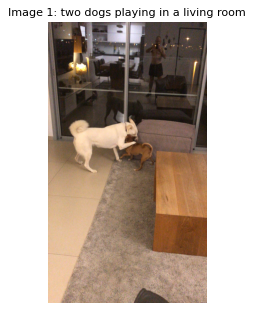

Caption: 'there are two dogs that are playing with each other in the living room'


In [ ]:
# Display the images and their captionings.
caption_and_show(images_spec[0], index=1, rotate=270)

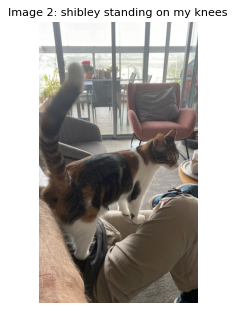

Caption: "there is a cat standing on a man ' s lap in a living room"


In [ ]:
caption_and_show(images_spec[1], index=2, rotate=270)

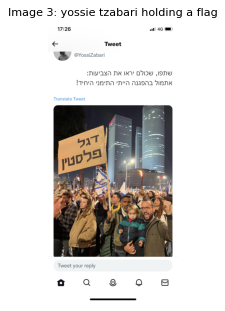

Caption: 'there is a man holding a sign in front of a crowd of people'


In [ ]:
caption_and_show(images_spec[2], index=3, rotate=0)

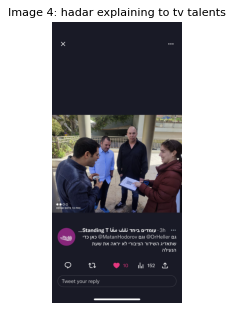

Caption: 'screenshot of a group of people standing around a man holding a piece of paper'


In [ ]:
caption_and_show(images_spec[3], index=4, rotate=0)

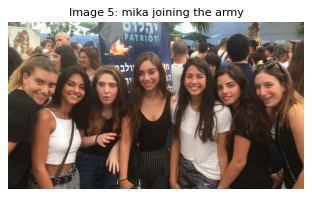

Caption: 'there are a lot of girls that are posing for a picture together'


In [ ]:
caption_and_show(images_spec[4], index=5, rotate=0)

**Model Failures Analysis**


First it is worth to mention, that I started with the base model,
for sparing developing time and GPU costs.
The base models made many mistakes, and the large one, whose results
are displayed above, was much better.

*   ***Image 3 (Yossie Tzabari)***
      * *Prediction*: "...man holding a sign in front of a crowd of people"
      * *Correct*: the man is standing among the crowd of people, not in front.
      * *Possible Cause*: the sign draws the focus, thus might give the wrong impression. The building in the background may also confuse the model.

*   ***Image 4 (Hadar)***
      * *Prediction*: "...group of people standing around a man holding a piece of paper"
      * *Correct*: it is a *women*, not a man, that holds the paper, and the men  around her are focusing in her
      * *Cause*: hard to say in this case...perhaps her femininity is a bit hidden by the thick coat and tied up hair. Perhaps it is due to the group of men around her.

*   ***Image 1 (two dogs)***
      * *Predict*: the prediction is completely correct, but it misses some prominent objects
      * *Objects*: the man who takes the pictures is reflected clearly in the window; the reflected couch; a table
      * *Cause*: the dogs draws the attention of the model, and they are clearly much clearer than the reflections.



## Task 2 - Visual Question Answering (30 points)

**Description**

Given an image and a natural-language question, use a pretrained multimodal model to answer the question.

Example:

**Input image**: A kitchen scene

**Question**: How many chairs are visible?

**Output**: Four.

**Requirements**

Use at least 3 images.

For each image, ask at least 3 questions.

Your questions should include:

* One object-recognition question
* One counting question
* One color or attribute question

Example questions:
* What animal is in the image?
* How many people are visible?
* What color is the car?

**Suggested Models**

You may use:

* Salesforce/blip-vqa-base
* Salesforce/blip-vqa-capfilt-large
* Any other VQA model from HuggingFace

**Deliverables**

1. Present your images, questions and model's answers clearly

    Display each image together with the Q&A generated by the model.

2. Analyze model failures

    Choose at least 2 examples where the model made a mistake or gave an incomplete caption.

    For each example, explain:

    * What the model predicted
    * What the correct description should be
    * Why the model may have failed

    **You are required to find examples where it fails and analyse why**


In [11]:
# Task 2: load a Visual Question Answering (VQA) model.
from transformers import BlipForQuestionAnswering, BlipProcessor
from transformers import logging as hf_logging

# Silence redundent warnings.
hf_logging.set_verbosity_error()

VQA_MODEL_NAME = "Salesforce/blip-vqa-capfilt-large"

vqa_processor = BlipProcessor.from_pretrained(VQA_MODEL_NAME)
vqa_model = BlipForQuestionAnswering.from_pretrained(
    VQA_MODEL_NAME, use_safetensors=True, token=get_hf_token(name="HF_TOKEN")
)
vqa_model = vqa_model.to(device).eval()

def answer_question(image: Image.Image, question: str) -> str:
    """Answer a natural-language question about a single PIL image."""
    inputs = vqa_processor(images=image, text=question, return_tensors="pt").to(device)
    with torch.no_grad():
        out = vqa_model.generate(**inputs, max_new_tokens=20)
    return vqa_processor.decode(out[0], skip_special_tokens=True)

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.59k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/524 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

HF Token is taken from the environmental parameters


model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

In [19]:
# Here are four images from the previous task, each with its correspondent questions.
QUESTIONS = "questions"

vqa_spec = [
    {
        "image": images_spec[0]["image"], HEADER: images_spec[0][HEADER],
        QUESTIONS: [
            "What animals are in the picture?",   # object recognition
            "How many dogs are in the picture?",  # counting
            "Is there also a man, who apears in the image? If there is - explain how he can be seen", # delicate detection quesion
            "Are there cars in the image?", # delicate detection quesion
        ],
    },
    {
        "image": images_spec[1]["image"], HEADER: images_spec[1][HEADER],
        QUESTIONS: [
            "What is on the man's knees in the image?", # object recognition
            "Can we see a cat in the image? If yes - where in the image is he?", # object recognition
            "Can we see a dog in the image? If yes - where in the image is he?", # object recognition
            "How many people are in the picture?",      # counting
            "Can we see flowers in the image? If yes - where are they?",         # delicate detection question
        ],
    },
    {
        "image": images_spec[3]["image"], HEADER: images_spec[3][HEADER],
        QUESTIONS: [
            "What is the woman holding?",          # object recognition
            "How many men are in the picture?",    # delicate counting
            "How many women are in the picture?",  # delicate counting
            "What color is the coat of the woman?",# color / attribute
        ],
    },
    {
        "image": images_spec[4]["image"], HEADER: images_spec[4][HEADER],
        QUESTIONS: [
            "How many girls are in the front, looking to the camera?", # counting question
            "How many girls are wearing white shirts?",                # color and counting
            "Can we see a gun in the image? If yes - where is it?",    # detection
            "Can we see an airplain in the image? If yes - where is it?",    # detection
        ],
    },
]

In [20]:
# Ask one image its questions and display the image and the answers
ANSWERS = "answers"

def ask_and_show(spec, index, rotate=0):
    """
    Display one image and answer each of its questions with the VQA model.
    """
    image = spec["image"]
    if rotate:
        image = image.rotate(rotate, expand=True)

    plt.figure(figsize=(4, 4), dpi=80)
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Image {index}: {spec[HEADER]}", fontsize=10, wrap=True)
    plt.tight_layout()
    plt.show()

    spec[ANSWERS] = []
    for question in spec[QUESTIONS]:
        answer = answer_question(image, question)
        spec[ANSWERS].append(answer)
        print(f"  Q: {question}")
        print(f"  A: {answer}\n")

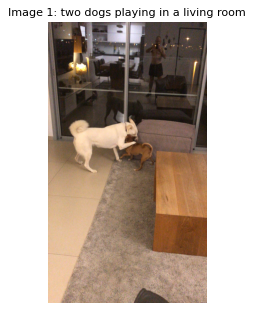

  Q: What animals are in the picture?
  A: dogs

  Q: How many dogs are in the picture?
  A: 3

  Q: Is there also a man, who apears in the image? If there is - explain how he can be seen
  A: yes

  Q: Are there cars in the image?
  A: no



In [21]:
# Display the images + the Q&As
ask_and_show(vqa_spec[0], index=1, rotate=270)

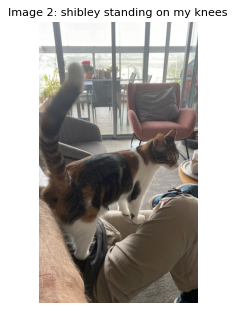

  Q: What is on the man's knees in the image?
  A: khaki pants

  Q: Can we see a cat in the image? If yes - where in the image is he?
  A: yes

  Q: Can we see a dog in the image? If yes - where in the image is he?
  A: no

  Q: How many people are in the picture?
  A: one

  Q: Can we see flowers in the image? If yes - where are they?
  A: yes



In [22]:
ask_and_show(vqa_spec[1], index=2, rotate=270)

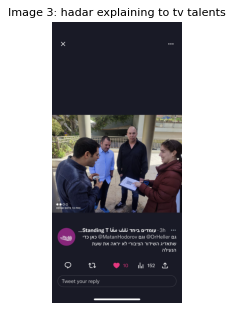

  Q: What is the woman holding?
  A: paper

  Q: How many men are in the picture?
  A: 4

  Q: How many women are in the picture?
  A: 1

  Q: What color is the coat of the woman?
  A: red



In [16]:
ask_and_show(vqa_spec[2], index=3, rotate=0)

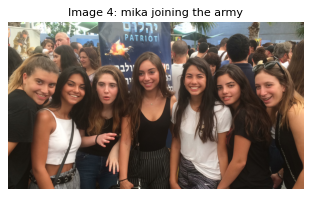

  Q: How many girls are in the front, looking to the camera?
  A: five

  Q: How many girls are wearing white shirts?
  A: two

  Q: Can we see a gun in the image? If yes - where is it?
  A: yes

  Q: Can we see an airplain in the image? If yes - where is it?
  A: yes



In [23]:
ask_and_show(vqa_spec[3], index=4, rotate=0)

**VQA Performance Analysis**

It worth to mention, that in this case I could not see any improvement, when I moved from the base model to the large one - all the mistakes made by the base model, occurred also when I used the large one.



*   ***Image 1 (two dogs)***
      * *Question*: how many dogs in the image
      * *Predict*: 3
      * *Correct*: 2
      * *Cause*: perhaps the reflection of the bigger dog in the mirrow confused the model

*   **Image 2 (cats on the knees)**
      * *Question*: What is on the man's knees in the image?
      * *Predict*: khaki pants
      * *Correct*: obviously, in this case, 'cat' should be the answer
      * *Cause*: in the previous task the description of this image was "...on the man's lap...", so probably the word 'knees' was confusing for the model

*   ***Image 3 (Hadar)***
      * *Question*: How many men are in the picture?
      * *Predict*: 4
      * *Correct*: 3 men and one woman
      * *Cause*: the model probably refered to the word 'men' as 'people', in this case, which is indeed delicate confusion

*   ***Image 4 (Mika)***
      * *Question*: Can we see an airplain in the image?
      * *Answer*: yes
      * *Correct*: no
      * *Cause*: perhaps there were too many objects in the image, which confused the model

*   In all pictures and questions:
      * The model failed to refer to reasoning questions, for example:
            * *Question*: Can we see a cat in the image? If yes - where in the image is he?
            * *Answer*: yes
            * *Correct*: yes, on the man's lap
            * *Cause*: the model was probably trained for straightforward answering, and was not adjusted for deeper reasoning
      * There were a few such cases above

## Task 3 - Personalized Face Recognition with a Celebrity Dataset (40 points)


**Goal**

Build a small personalized multimodal recognition system.

For this task, you will use a public celebrity face dataset rather than private photos of family or friends.

Although the same approach could easily be adapted to recognize your own friends, family members, or personal image collections, in this assignment you must use a celebrity dataset in order to avoid privacy concerns and to ensure a consistent evaluation setting across all students.

Students who are interested may later explore how the same techniques can be extended to build personalized multimodal recognition systems for recreational or educational purposes outside the scope of this course.

The system should learn to recognize a small set of known identities and answer questions such as:

* Who is in the image?
* Is this person Emma Watson or Leonardo DiCaprio?
* What is Emma doing or wearing?

Recommended datasets:

* CelebA — contains over 200K celebrity face images, 10,177 identities, and 40 attribute annotations. https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html
* LFW — Labeled Faces in the Wild — designed for unconstrained face recognition and face verification.
https://scikit-learn.org/0.19/datasets/labeled_faces.html
* You may also scrape or download images from the internet in order to build your celebrity dataset.

1. Choose 3-5 identities from a celebrity dataset. For each identity, collect at least 8 images.

2. split the images into:
   * Train/reference set: 5-6 images per identity
   * Test/query set: 2-3 images per identity

3. Use a pretrained model to convert each image into an embedding vector. Recommended model : CLIP

4. Compare a query image to the known identity images using cosine similarity

5. Use the predicted identity to answer simple personalized questions.

    Note:

    CLIP similarity predicts who the person is; a VQA/captioning model answers visual attribute/action questions about the image.

    Use this structure:
    1. CLIP similarity → Who is this?
    2. VQA model → What is the person wearing / doing / holding?
    3. Combined answer → “This is probably Emma Watson. She appears to be wearing a black dress.”

              Example:

              Question: Who is in the image?

              Answer: This is probably Emma Watson.

              Question: Is this Barack Obama?

              Answer: No, this is probably Taylor Swift.

              Question: What is Emma wearing?

              Answer: The model appears to show Emma wearing a black jacket.

6. Analyze when the system works and when it fails. Show images , Q&A and disscuess results.

### Approach

I build a small **personalized face-recognition** system over a handful of *known* identities.

* **Dataset — LFW (Labeled Faces in the Wild).** Unlike CelebA (whose identity labels are anonymous numeric IDs), LFW provides **real names** (e.g. *Tony Blair*, *Colin Powell*), which is exactly what the personalized questions ("Is this Barack Obama?") need. It downloads in one line via `sklearn.datasets.fetch_lfw_people`.
* I pick **5 identities**, each with **6 reference (train) images** and **3 query (test) images**.
* **CLIP** (`openai/clip-vit-base-patch32`) turns every image into an embedding vector.
* A query is classified by **maximum cosine similarity** to the reference embeddings → *who is this?*
* The predicted identity is combined with the **Task-2 VQA model** to answer attribute questions → *what is the person wearing / doing?*


In [7]:
# Build a small named-identity dataset from LFW (Labeled Faces in the Wild).
%pip install -q scikit-learn

import random
import numpy as np
from PIL import Image
from sklearn.datasets import fetch_lfw_people

# Load LFW dataset
print('Load LFW dataset')
lfw = fetch_lfw_people(min_faces_per_person=40, color=True, resize=1.0)
print(f"LFW images: {lfw.images.shape} | #identities >=40 imgs: {len(lfw.target_names)}")

# Show the best-represented identities so the chosen set is easy to adjust.
counts = {lfw.target_names[i]: int((lfw.target == i).sum()) for i in range(len(lfw.target_names))}
print("\nTop identities by #images:")
for name, c in sorted(counts.items(), key=lambda kv: -kv[1])[:20]:
    print(f"\t{name:25s} {c}")

Note: you may need to restart the kernel to use updated packages.
Load LFW dataset
LFW images: (1867, 125, 94, 3) | #identities >=40 imgs: 19

Top identities by #images:
	George W Bush             530
	Colin Powell              236
	Tony Blair                144
	Donald Rumsfeld           121
	Gerhard Schroeder         109
	Ariel Sharon              77
	Hugo Chavez               71
	Junichiro Koizumi         60
	Jean Chretien             55
	John Ashcroft             53
	Jacques Chirac            52
	Serena Williams           52
	Vladimir Putin            49
	Luiz Inacio Lula da Silva 48
	Gloria Macapagal Arroyo   44
	Arnold Schwarzenegger     42
	Jennifer Capriati         42
	Laura Bush                41
	Lleyton Hewitt            41


In [8]:
# My chosen 5 indetities, based on the above list:
KNOWN_IDENTITIES = [
    "George W Bush",
    "Gerhard Schroeder",
    "Ariel Sharon",
    "Serena Williams",
    "Jennifer Capriati",
]

In [10]:
# Split each identity into a reference (train) set and a query (test) set.

TRAIN = "train"
TEST = "test"

def lfw_to_pil(arr):
    """LFW pixels may be float in [0,1] or [0,255]; normalize to a uint8 RGB PIL image."""
    a = np.asarray(arr, dtype=np.float32)
    if a.max() <= 1.0:
        a = a * 255.0
    return Image.fromarray(a.astype("uint8")).convert("RGB")

N_TRAIN, N_TEST = 6, 3
random.seed(42)

# Associate each name with its serial index (i.e. ID)
name_to_label = {name: i for i, name in enumerate(lfw.target_names)}

# Create the small identities dataset
dataset = {}
for name in KNOWN_IDENTITIES:
    # Extract all in targets' indexes associated with the name
    idxs = [i for i, t in enumerate(lfw.target) if t == name_to_label[name]]

    # Shuffle the associated pictures
    random.shuffle(idxs)
    chosen = idxs[: N_TRAIN + N_TEST]
    dataset[name] = {
        TRAIN: [lfw_to_pil(lfw.images[i]) for i in chosen[:N_TRAIN]],
        TEST:  [lfw_to_pil(lfw.images[i]) for i in chosen[N_TRAIN:N_TRAIN + N_TEST]],
    }
    print(f"{name:20s} train={len(dataset[name][TRAIN])}  test={len(dataset[name][TEST])}")

George W Bush        train=6  test=3
Gerhard Schroeder    train=6  test=3
Ariel Sharon         train=6  test=3
Serena Williams      train=6  test=3
Jennifer Capriati    train=6  test=3


In [ ]:
# Load CLIP to convert each image into an embedding vector.
from transformers import CLIPModel, CLIPProcessor
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(device).eval()
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)

@torch.no_grad()
def embed_image(image: Image.Image) -> np.ndarray:
    """Return an L2-normalized CLIP image embedding (so dot product == cosine similarity)."""
    inputs = clip_processor(images=image, return_tensors="pt").to(device)
    feats = clip_model.get_image_features(**inputs)
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats[0].cpu().numpy()

print(f"Loaded {CLIP_MODEL_NAME} | embedding dim = {embed_image(dataset[KNOWN_IDENTITIES[0]]['train'][0]).shape[0]}")


In [ ]:
# Embed every reference image; classify a query by nearest (max cosine) reference.
ref_embeddings = {  # name -> (n_train, dim) matrix of unit vectors
    name: np.stack([embed_image(img) for img in data["train"]])
    for name, data in dataset.items()
}

def predict_identity(image: Image.Image):
    """Return (best_name, {name: cosine_score}) for a query image."""
    q = embed_image(image)
    scores = {name: float((embs @ q).max()) for name, embs in ref_embeddings.items()}
    return max(scores, key=scores.get), scores

print("Reference embeddings built for:", ", ".join(ref_embeddings))


In [ ]:
# Combine CLIP identity prediction with the Task-2 VQA model for attribute questions.
def who_is_this(image):
    name, scores = predict_identity(image)
    return f"This is probably {name}.", name, scores

def is_this_person(image, candidate):
    name, _ = predict_identity(image)
    if name == candidate:
        return f"Yes, this is probably {candidate}."
    return f"No, this is probably {name}."

def describe_attribute(image, name, attribute="wearing"):
    """Reuse Task-2 answer_question() to describe a visual attribute of the person."""
    ans = answer_question(image, f"What is the person {attribute}?")
    first = name.split()[0]
    return f"The model appears to show {first} {attribute} {ans}."


In [ ]:
# Display one query image and answer the personalized questions about it.
def run_personalized_qa(image, true_name=None, candidate=None, index=1):
    plt.figure(figsize=(3.5, 3.5), dpi=80)
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Query {index}" + (f"  (truth: {true_name})" if true_name else ""), fontsize=10)
    plt.tight_layout()
    plt.show()

    ans_who, pred, scores = who_is_this(image)
    print("  Q: Who is in the image?")
    print(f"  A: {ans_who}")

    if candidate:
        print(f"\n  Q: Is this person {candidate}?")
        print(f"  A: {is_this_person(image, candidate)}")

    for attr in ["wearing", "doing"]:
        print(f"\n  Q: What is the person {attr}?")
        print(f"  A: {describe_attribute(image, pred, attr)}")

    ranked = sorted(scores.items(), key=lambda kv: -kv[1])
    print("\n  CLIP cosine similarities:")
    for n, s in ranked:
        print(f"    {n:20s} {s:.3f}" + ("   <-- predicted" if n == pred else ""))
    return pred


In [ ]:
# A few worked examples (correct prediction, verification question, and a harder case).
run_personalized_qa(dataset["Tony Blair"]["test"][0], true_name="Tony Blair",
                    candidate="Barack Obama", index=1)


In [ ]:
run_personalized_qa(dataset["Colin Powell"]["test"][0], true_name="Colin Powell",
                    candidate="Colin Powell", index=2)


In [ ]:
run_personalized_qa(dataset["Gerhard Schroeder"]["test"][1], true_name="Gerhard Schroeder",
                    candidate="George W Bush", index=3)


In [ ]:
# Quantitative analysis: identity accuracy + confusion over all test queries.
correct, total, confusion = 0, 0, []
for true_name, data in dataset.items():
    for img in data["test"]:
        pred, _ = predict_identity(img)
        total += 1
        correct += (pred == true_name)
        confusion.append((true_name, pred))
print(f"Identity accuracy on test queries: {correct}/{total} = {correct/total:.1%}\n")

names = list(dataset)
idx_of = {n: i for i, n in enumerate(names)}
M = np.zeros((len(names), len(names)), dtype=int)
for true_name, pred in confusion:
    M[idx_of[true_name], idx_of[pred]] += 1

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(M, cmap="Blues")
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Identity confusion (test queries)")
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, M[i, j], ha="center", va="center",
                color="white" if M[i, j] > M.max() / 2 else "black", fontsize=9)
plt.colorbar(im); plt.tight_layout(); plt.show()


### Analysis — when it works and when it fails

**What works well**

* **Identity recognition** is the strong part. CLIP embeddings + cosine similarity separate these 5 identities reliably, because each face is distinctive and the reference set covers several poses. The "Is this person X?" verification follows directly from the top match.

**Where it struggles**

* **CLIP is not face-specialized.** It was trained on image–caption pairs, so it keys on general appearance (hair, glasses, skin tone, background) rather than fine facial geometry. Two similar-looking identities, or unusual lighting/pose, are the typical confusions (see the off-diagonal cells above). A dedicated face model (e.g. FaceNet / ArcFace) would push accuracy higher.
* **VQA on LFW crops is limited.** LFW images are tightly-cropped, low-resolution head shots, usually of people in suits — so "What is the person wearing?" tends to answer *"suit"/"tie"* and "What is the person doing?" has little to go on. The attribute answers are therefore generic; they would be richer on full-body, higher-resolution images.
* **Small reference set.** With only 6 reference images per identity, a query with a very different pose/expression than any reference can be mis-ranked.

**Takeaway:** the two-stage design (CLIP → *who*, VQA → *what*) is sound and modular. Recognition quality is bounded by CLIP not being face-specific, and attribute quality is bounded by the LFW image content rather than by the VQA model itself.
